In [38]:
import torch
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(0)

In [39]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def softmax(z):
    z = z - z.max(dim=1, keepdim=True)[0]
    return torch.exp(z) / torch.exp(z).sum(dim=1, keepdim=True)

In [40]:
def bce(p, y):
    return -(y * torch.log(p) + (1 - y) * torch.log(1 - p)).mean()

def cce(p, y):
    return -(y * torch.log(p)).sum(dim=1).mean()

def mse(y_hat, y):
    return ((y_hat - y) ** 2).mean()

def mae(y_hat, y):
    return torch.abs(y_hat - y).mean()

In [41]:
def forward(X, W1, b1, W2, b2, out="sigmoid"):
    h = sigmoid(X @ W1 + b1)
    z = h @ W2 + b2
    if out == "sigmoid":
        return sigmoid(z)
    if out == "softmax":
        return softmax(z)
    return z

In [42]:
def cf_mat(X, y, W1, b1, W2, b2):
    with torch.no_grad():
        probs = forward(X, W1, b1, W2, b2, out="sigmoid")
        preds = (probs > 0.5).int().view(-1).numpy()

    y_true = y.view(-1).numpy().astype(int)

    # confusion matrix values
    TP = np.sum((preds == 1) & (y_true == 1))
    TN = np.sum((preds == 0) & (y_true == 0))
    FP = np.sum((preds == 1) & (y_true == 0))
    FN = np.sum((preds == 0) & (y_true == 1))

    cm = np.array([[TN, FP],
                [FN, TP]])

    print("Confusion Matrix:")
    print(cm)

In [43]:
df = pd.read_csv("pumpkin_seeds.csv", encoding="latin1")
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values
classes = np.unique(y_raw)
y = (y_raw == classes[1]).astype(np.float32).reshape(-1, 1)

X = torch.tensor(StandardScaler().fit_transform(X), dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

D, H = X.shape[1], 16
W1 = torch.randn(D, H) * 0.1
b1 = torch.zeros(H)
W2 = torch.randn(H, 1) * 0.1
b2 = torch.zeros(1)

p = forward(X, W1, b1, W2, b2, out="sigmoid")
print("Pumpkin BCE:", bce(p, y).item())

cf_mat(X, y, W1, b1, W2, b2)

Pumpkin BCE: 0.7013399600982666
Confusion Matrix:
[[   0 1300]
 [   2 1198]]


In [44]:
def confusion_matrix_multiclass(X, y_onehot, forward_fn, params):
    W1, b1, W2, b2 = params

    with torch.no_grad():
        probs = forward_fn(X, W1, b1, W2, b2, out="softmax")
        y_pred = torch.argmax(probs, dim=1).cpu().numpy()

    y_true = torch.argmax(y_onehot, dim=1).cpu().numpy()
    C = y_onehot.shape[1]

    cm = np.zeros((C, C), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    return cm

In [45]:
iris = load_iris()
X = iris.data
y = iris.target
C = len(np.unique(y))
y_oh = np.eye(C)[y]

X = torch.tensor(StandardScaler().fit_transform(X), dtype=torch.float32)
y_oh = torch.tensor(y_oh, dtype=torch.float32)

D, H = X.shape[1], 16
W1 = torch.randn(D, H) * 0.1
b1 = torch.zeros(H)
W2 = torch.randn(H, C) * 0.1
b2 = torch.zeros(C)

p = forward(X, W1, b1, W2, b2, out="softmax")
print("Iris CCE:", cce(p, y_oh).item())

cm = confusion_matrix_multiclass(
    X, y_oh,
    forward_fn=forward,
    params=(W1, b1, W2, b2)
)

print("Confusion Matrix (Iris):")
print(cm)


Iris CCE: 1.1186383962631226
Confusion Matrix (Iris):
[[ 0 50  0]
 [ 0 50  0]
 [ 0 50  0]]


In [46]:
house = fetch_california_housing()
X = house.data
y = house.target.reshape(-1, 1)

X_train, _, y_train, _ = train_test_split(X, y, train_size=2000)

X = torch.tensor(StandardScaler().fit_transform(X_train), dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.float32)

D, H = X.shape[1], 32
W1 = torch.randn(D, H) * 0.1
b1 = torch.zeros(H)
W2 = torch.randn(H, 1) * 0.1
b2 = torch.zeros(1)

y_hat = forward(X, W1, b1, W2, b2, out="linear")
print("House MSE:", mse(y_hat, y).item())
print("House MAE:", mae(y_hat, y).item())

House MSE: 4.5280351638793945
House MAE: 1.7827237844467163


In [47]:
def relu(x): return np.maximum(0, x)
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

def binary_forward_prop(X_batch, W1, b1, W2, b2):
    h = relu(X_batch @ W1 + b1)      
    logits = h @ W2 + b2             
    probs = sigmoid(logits)
    return probs

def bce_loss_from_probs(p, y, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

In [48]:
data = load_breast_cancer()
X = data["data"].astype(np.float32) 
y = data["target"].astype(np.float32).reshape(-1, 1) 

scaler = StandardScaler().fit(X)
X = scaler.transform(X)

N, D = X.shape
H = 16  
scale = 0.1

W1 = np.random.randn(D, H) * scale
b1 = np.zeros((1, H))
W2 = np.random.randn(H, 1) * scale
b2 = np.zeros((1, 1))

In [49]:
def run_stochastic_epochs(X, y, W1, b1, W2, b2, epochs=10):
    epoch_losses = []
    epoch_times = []

    for ep in range(1, epochs+1):
        t0 = time.time()
        losses = []

        for i in range(X.shape[0]):
            xb = X[i:i+1]
            yb = y[i:i+1]
            p = binary_forward_prop(xb, W1, b1, W2, b2)
            loss = bce_loss_from_probs(p, yb)
            losses.append(loss)

        avg_loss = float(np.mean(losses))
        epoch_losses.append(avg_loss)
        epoch_times.append(time.time() - t0)

        print(f"[Stochastic][Epoch {ep}] loss={avg_loss:.6f} time={epoch_times[-1]:.3f}s")

    return epoch_losses, epoch_times

In [50]:
def run_minibatch_epochs(X, y, W1, b1, W2, b2, batch_size=50, epochs=10):
    epoch_losses = []
    epoch_times = []

    N = X.shape[0]

    for ep in range(1, epochs+1):
        t0 = time.time()
        losses = []

        for i in range(0, N, batch_size):
            xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]
            p = binary_forward_prop(xb, W1, b1, W2, b2)
            loss = bce_loss_from_probs(p, yb)
            losses.append(loss)

        avg_loss = float(np.mean(losses))
        epoch_losses.append(avg_loss)
        epoch_times.append(time.time() - t0)

        print(f"[Mini-batch][Epoch {ep}] loss={avg_loss:.6f} time={epoch_times[-1]:.3f}s")

    return epoch_losses, epoch_times


In [51]:
def run_fullbatch_epochs(X, y, W1, b1, W2, b2, epochs=10):
    epoch_losses = []
    epoch_times = []

    for ep in range(1, epochs+1):
        t0 = time.time()
        p = binary_forward_prop(X, W1, b1, W2, b2)
        loss = float(bce_loss_from_probs(p, y))
        epoch_losses.append(loss)
        epoch_times.append(time.time() - t0)

        print(f"[Full-batch][Epoch {ep}] loss={loss:.6f} time={epoch_times[-1]:.3f}s")

    return epoch_losses, epoch_times


In [52]:
epochs = 10

In [53]:
loss_s, time_s = run_stochastic_epochs(X, y, W1, b1, W2, b2, epochs)

[Stochastic][Epoch 1] loss=0.688605 time=0.012s
[Stochastic][Epoch 2] loss=0.688605 time=0.008s
[Stochastic][Epoch 3] loss=0.688605 time=0.008s
[Stochastic][Epoch 4] loss=0.688605 time=0.008s
[Stochastic][Epoch 5] loss=0.688605 time=0.009s
[Stochastic][Epoch 6] loss=0.688605 time=0.008s
[Stochastic][Epoch 7] loss=0.688605 time=0.008s
[Stochastic][Epoch 8] loss=0.688605 time=0.011s
[Stochastic][Epoch 9] loss=0.688605 time=0.009s
[Stochastic][Epoch 10] loss=0.688605 time=0.009s


In [54]:
loss_m, time_m = run_minibatch_epochs(X, y, W1, b1, W2, b2, batch_size=50, epochs=epochs)

[Mini-batch][Epoch 1] loss=0.688749 time=0.001s
[Mini-batch][Epoch 2] loss=0.688749 time=0.000s
[Mini-batch][Epoch 3] loss=0.688749 time=0.001s
[Mini-batch][Epoch 4] loss=0.688749 time=0.000s
[Mini-batch][Epoch 5] loss=0.688749 time=0.000s
[Mini-batch][Epoch 6] loss=0.688749 time=0.000s
[Mini-batch][Epoch 7] loss=0.688749 time=0.001s
[Mini-batch][Epoch 8] loss=0.688749 time=0.000s
[Mini-batch][Epoch 9] loss=0.688749 time=0.000s
[Mini-batch][Epoch 10] loss=0.688749 time=0.000s


In [55]:
loss_f, time_f = run_fullbatch_epochs(X, y, W1, b1, W2, b2, epochs)

[Full-batch][Epoch 1] loss=0.688605 time=0.001s
[Full-batch][Epoch 2] loss=0.688605 time=0.000s
[Full-batch][Epoch 3] loss=0.688605 time=0.001s
[Full-batch][Epoch 4] loss=0.688605 time=0.000s
[Full-batch][Epoch 5] loss=0.688605 time=0.000s
[Full-batch][Epoch 6] loss=0.688605 time=0.000s
[Full-batch][Epoch 7] loss=0.688605 time=0.000s
[Full-batch][Epoch 8] loss=0.688605 time=0.001s
[Full-batch][Epoch 9] loss=0.688605 time=0.000s
[Full-batch][Epoch 10] loss=0.688605 time=0.000s


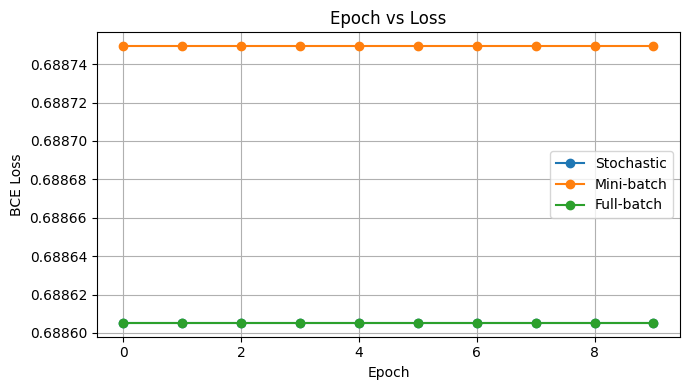

In [62]:
plt.figure(figsize=(7,4))
plt.plot(loss_s, label="Stochastic", marker='o')
plt.plot(loss_m, label="Mini-batch", marker='o')
plt.plot(loss_f, label="Full-batch", marker='o')

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Epoch vs Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


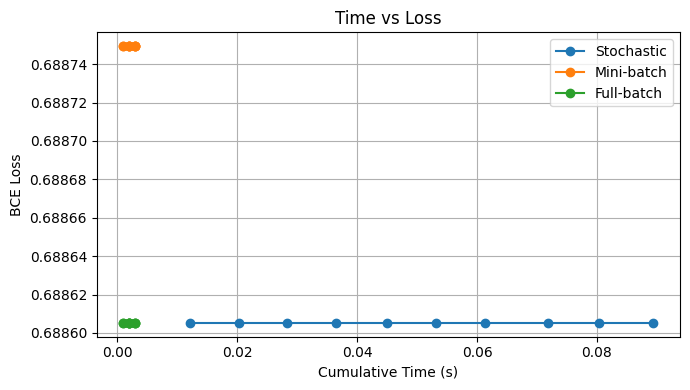

In [57]:
plt.figure(figsize=(7,4))
plt.plot(np.cumsum(time_s), loss_s, label="Stochastic", marker='o')
plt.plot(np.cumsum(time_m), loss_m, label="Mini-batch", marker='o')
plt.plot(np.cumsum(time_f), loss_f, label="Full-batch", marker='o')

plt.xlabel("Cumulative Time (s)")
plt.ylabel("BCE Loss")
plt.title("Time vs Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
